In [36]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import h5py

# file_path = r"C:\\Users\\qcrew\\Desktop\\Juncheng\\victoria\\data\\2026-07-05\\18-27-49_OutAndBackChi.hdf5"
file_path = r"C:\\Users\\qcrew\\Desktop\\Juncheng\\victoria\\data\\2026-07-05\\19-11-49_OutAndBackChi.hdf5"
#"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-05\18-27-49_OutAndBackChi.hdf5"

# r"C:\Users\qcrew2\Documents\Candace\eunice\data\2026-04-08\12-55-53_OutAndBackChi.hdf5"
# "C:\Users\qcrew2\Documents\Candace\eunice\data\2026-04-08\12-55-53_OutAndBackChi.hdf5"
# with h5py.File(file_path, "r") as f:
#     print(list(f.keys()))        # top-level groups/datasets

# latest_file =r"08-14-19_OUTANDBACK.hdf5"

# READ DATA
data = h5py.File(file_path, "r")

disp_phase = np.array(data["disp_phase"])
time_delays = np.array(data["time_delay"]) 

mean_intensity = np.mean(np.array(data["Q"]), axis=0)

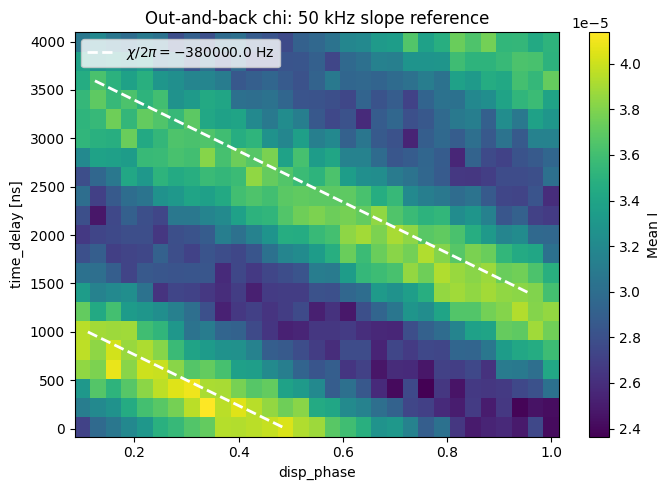

In [34]:
# ==========================================================
# Plot phase vs time with 50 kHz reference slope
# ==========================================================

freq_ref = -380e3   # Hz, this is chi/2pi reference line

# Choose phase units:
# "cycle" if disp_phase goes from 0 to 1
# "rad"   if disp_phase goes from 0 to 2*pi or -pi to pi
phase_units = "cycle"

x = disp_phase
y = time_delays

# Convert time to seconds
# Assuming time_delay is in ns
t_s = y * 1e-9

Z = mean_intensity

# Make sure Z has shape (len(time_delays), len(disp_phase))
if Z.shape == (len(x), len(y)):
    Z = Z.T
elif Z.shape != (len(y), len(x)):
    raise ValueError(
        f"Unexpected shape: mean_intensity has shape {Z.shape}, "
        f"but expected {(len(y), len(x))} or {(len(x), len(y))}"
    )

# Pick starting phase automatically from the first time slice
# You can also manually set this, e.g. phase0 = 0.53
phase0 = x[np.argmax(Z[0])]

plt.figure(figsize=(7, 5))
plt.pcolormesh(x, y, Z, shading="auto")
plt.colorbar(label="Mean I")

if phase_units == "cycle":
    # phase advances as phase = phase0 + f * t
    phase_line = phase0 + freq_ref * t_s
    period = 1.0
    label = f"$\chi/2\pi = {freq_ref}$ Hz"

elif phase_units == "rad":
    # phase advances as phase = phase0 + 2*pi*f*t
    phase_line = phase0 + 2 * np.pi * freq_ref * t_s
    period = 2 * np.pi
    label = f"$\chi/2\pi = {freq_ref}$ Hz"

else:
    raise ValueError("phase_units must be 'cycle' or 'rad'")

# Plot wrapped copies of the reference line so it appears correctly on the phase axis
xmin, xmax = np.min(x), np.max(x)

for k in range(-5, 6):
    line = phase_line - k * period
    mask = (line >= xmin) & (line <= xmax)
    if np.any(mask):
        plt.plot(line[mask], y[mask], "w--", linewidth=2, label=label if k == 0 else None)

plt.xlabel("disp_phase")
plt.ylabel("time_delay [ns]")
plt.title("Out-and-back chi: 50 kHz slope reference")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
def gaussian(x, A, C, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + C

def line_fit(x, m, n):
    return m * x + n


In [67]:
# plt.plot(disp_phase, gaussian(disp_phase, 0.00016, -0.00016, 0.5, 0.05))

In [38]:
if 0:
    mu_list = []
    for i, delay in enumerate(time_delays):
        A_initial = np.max([mean_intensity[a][i] for a in range(len(mean_intensity))]) - np.min([mean_intensity[a][i] for a in range(len(mean_intensity))])
        C_initial = np.min([mean_intensity[a][i] for a in range(len(mean_intensity))])
        popt, pcov = curve_fit(gaussian, disp_phase, [mean_intensity[a][i] for a in range(len(mean_intensity))], p0=[A_initial, C_initial, 0.5, 0.05])
        A, C, mu, sigma = popt
        mu_list.append(mu)

    m_initial = np.max(mu_list) - np.min(mu_list)
    n_initial = np.min(mu_list)

    popt, pcov = curve_fit(line_fit, time_delays, mu_list, p0=[m_initial, n_initial])
    m, n = popt


In [39]:
max_list = []
for i in range(len(time_delays)):
    # print(i)
    max_list = np.max(mean_intensity, axis=1)
    # max_list.append(max)

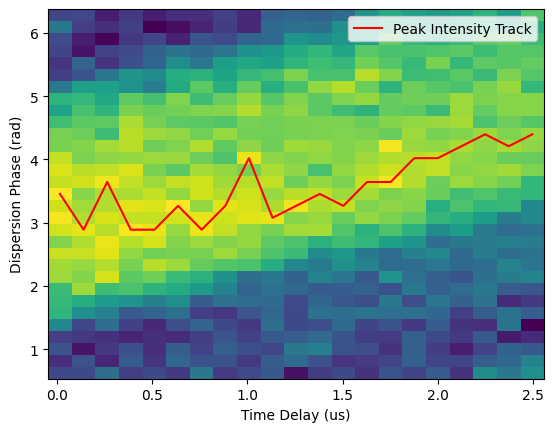

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Find the index of the max intensity for each time delay (along axis 0)
# This assumes mean_intensity has shape (len(disp_phase), len(time_delays))
max_indices = np.argmax(mean_intensity, axis=0)

# 2. Map those indices to the actual dispersion phase values
best_phases = disp_phase[max_indices] * 2 * np.pi

# 3. Plotting
plt.pcolormesh(time_delays / 1e3, disp_phase * 2 * np.pi, mean_intensity, shading='auto')

# Plot the tracked peak as a line or points
plt.plot(time_delays / 1e3, best_phases, 'r-', label="Peak Intensity Track")

plt.xlabel("Time Delay (us)")
plt.ylabel("Dispersion Phase (rad)")
plt.legend()
plt.show()

In [41]:
# Assuming mean_intensity shape is (len(disp_phase), len(time_delays))
max_indices = np.argmax(mean_intensity, axis=0)

# # Convert indices to actual physical units (radians)
# x_data = time_delays / 1e3  # In microseconds
# y_data = disp_phase[max_indices] * 2 * np.pi  # In radians


# Convert indices to actual physical units (radians)
x_data = time_delays[6:] / 1e3  # In microseconds
y_data = disp_phase[max_indices][6:] * 2 * np.pi  # In radians

# m is the slope, n is the intercept
m, n = np.polyfit(x_data, y_data, 1)

# Generate the fit line for plotting
fit_line = m * x_data + n

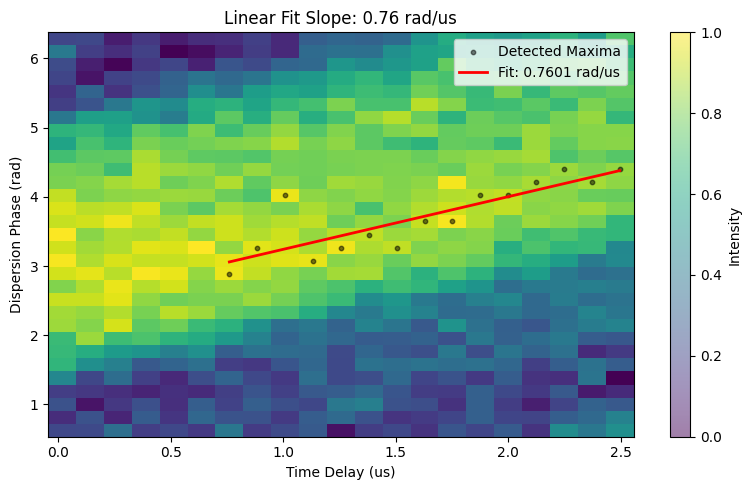

The extracted slope is: 0.7600627689739032 rad/us


In [42]:
plt.figure(figsize=(8, 5))

# Plot the heatmap
plt.pcolormesh(time_delays / 1e3, disp_phase * 2 * np.pi, mean_intensity, shading='auto')

# Plot the detected peaks (as points)
plt.scatter(x_data, y_data, color='black', s=10, label="Detected Maxima", alpha=0.5)

# Plot the linear fit
plt.plot(x_data, fit_line, color='red', linewidth=2, 
         label=f"Fit: {m:.4f} rad/us")

plt.xlabel("Time Delay (us)")
plt.ylabel("Dispersion Phase (rad)")
plt.title(f"Linear Fit Slope: {m:.2f} rad/us")
plt.legend()
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

print(f"The extracted slope is: {m} rad/us")

Slope: 0.7601 rad/us
Slope: 120.97 kHz


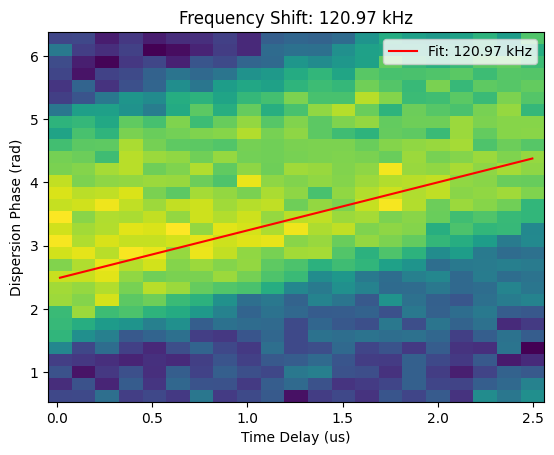

In [43]:
# 1. Perform the fit (m is in rad/us)
m, n = np.polyfit(time_delays[6:] / 1e3, disp_phase[max_indices][6:] * 2 * np.pi, 1)

# 2. Convert rad/us to kHz
# (m * 10^6 rad/s) / (2*pi rad/cycle) / 1000
slope_khz = (m * 1000) / (2 * np.pi)

print(f"Slope: {m:.4f} rad/us")
print(f"Slope: {slope_khz:.2f} kHz")

# 3. Update the Plot Title
plt.pcolormesh(time_delays / 1e3, disp_phase * 2 * np.pi, mean_intensity, shading='auto')
plt.plot(time_delays / 1e3, m * (time_delays / 1e3) + n, color='red', 
         label=f"Fit: {slope_khz:.2f} kHz")

plt.xlabel("Time Delay (us)")
plt.ylabel("Dispersion Phase (rad)")
plt.title(f"Frequency Shift: {slope_khz:.2f} kHz")
plt.legend()
plt.show()